💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


Predicting DataLoader 0: 100%|██████████| 597/597 [00:04<00:00, 119.45it/s]


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


Predicting DataLoader 0:   4%|▍         | 18/429 [00:00<00:04, 88.50it/s]

/data/home/natant/Negatives/TFBS_negatives/TFBS_negatives/models.py:242: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_DNA = self.DNA_branch(self.embedding(torch.tensor(x_DNA_in, dtype=torch.int)).permute(0, 2, 1))


...

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


Predicting DataLoader 0:   5%|▍         | 28/597 [00:00<00:04, 136.97it/s]

/data/home/natant/Negatives/TFBS_negatives/TFBS_negatives/models.py:242: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_DNA = self.DNA_branch(self.embedding(torch.tensor(x_DNA_in, dtype=torch.int)).permute(0, 2, 1))


Predicting DataLoader 0: 100%|██████████| 597/597 [00:04<00:00, 147.35it/s]


KeyboardInterrupt: 

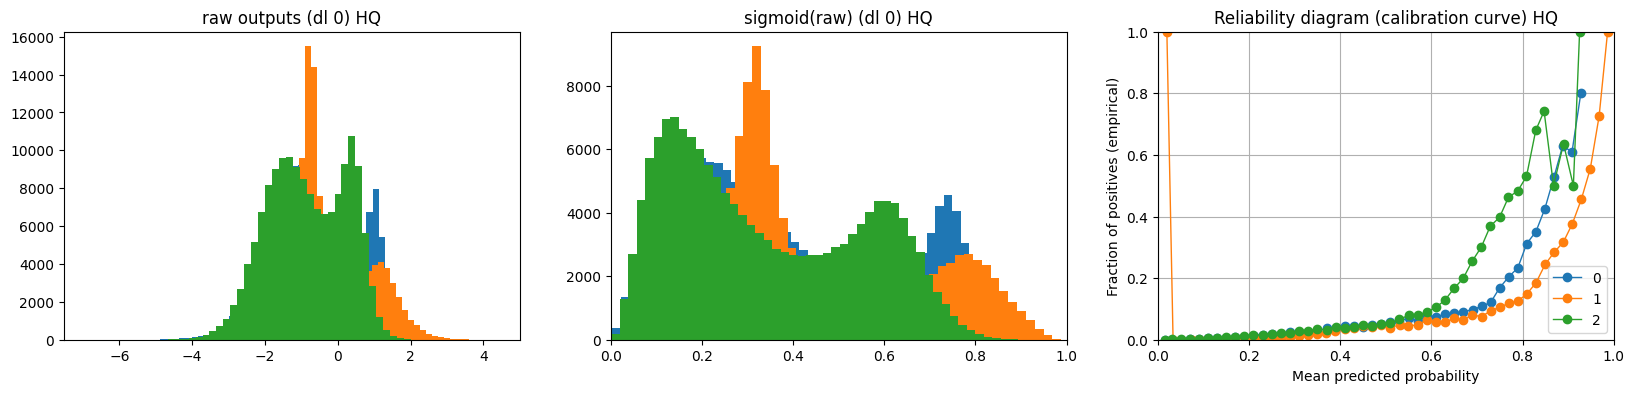

In [ ]:
import h5torch
import numpy as np
import torch
import pytorch_lightning as pl
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
import warnings
from pytorch_lightning.callbacks import Callback
from TFBS_negatives.data import DataModule_HQ
import pytorch_lightning as pl
from TFBS_negatives.models import TFmodel_HQ
from pytorch_lightning.callbacks import ModelCheckpoint
import torch
import pytorch_lightning as pl
import warnings
import numpy as np
import os
from torchmetrics.classification import MultilabelAUROC, MultilabelAveragePrecision
from torchmetrics.functional.classification import multilabel_average_precision, binary_auroc, binary_average_precision, binary_accuracy, binary_matthews_corrcoef, binary_precision, binary_specificity, binary_recall
import gc
#

def get_predicts(model_ckpt_path, device=3, idx=0):
    filename = os.path.basename(model_ckpt_path)
    for old_name, new_name in convert_dict.items():
        filename = filename.replace(old_name, new_name)
    parts = filename.split('_')
    
    # Extract cell line (first part)
    cellline = parts[0]    
    cv_split = parts[-7].split('-')[1]
    tf = '_'.join(parts[1:-7])

    Dmod = DataModule_HQ(cellline_file, TF=tf, batch_size=256, cross_val_set=int(cv_split))
    model = TFmodel_HQ.load_from_checkpoint(model_ckpt_path)

    trainer = pl.Trainer(
        max_steps=5_000_000,
        accelerator="gpu",
        devices=[device]
    )
    predict_outputs = trainer.predict(model, Dmod)
    return predict_outputs

cellline_file = "/data/home/natant/Negatives/Data/Encode690/ENCODE_hg38_subset_101bp_celltypes_ATAC_H5_all_chr/GM12878.h5t"


# Define the folder path
folder_path = "/data/home/natant/Negatives/Runs/Review_rerun"

# Get all files ending in .ckpt
ckpt_files = [f for f in os.listdir(folder_path) if f.endswith('.ckpt')]

convert_dict = {
    "dinucl_sampled": "dinucl-sampled",
    "dinucl_shuffled": "dinucl-shuffled",
}

# Parse each filename to extract information
data = []
negative_types = ["dinucl-sampled", "celltype", "shuffled", "dinucl-shuffled", "neighbors"]
for filename in ckpt_files:   
    old_filename = filename
    for old_name, new_name in convert_dict.items():
        filename = filename.replace(old_name, new_name)
    parts = filename.split('_')
    neg_type = parts[-8]
    if neg_type not in negative_types:
        neg_type = "HQ"
        tf = '_'.join(parts[1:-7])
    else:
        tf = '_'.join(parts[1:-8])
        neg_type = parts[-8]

    
    # Extract cell line (first part)
    cellline = parts[0] 
    cv_split = parts[-7].split('-')[1]


    
    
    data.append({
        'filename': filename,
        'file_path': os.path.join(folder_path, old_filename),
        'cellline': cellline,
        'TF': tf,
        'negative_type': neg_type,
        'cv_split': cv_split
    })

# Create DataFrame
df_ckpt = pd.DataFrame(data)


output_folder = "/data/home/natant/Negatives/Runs/Review_rerun/Calibration_plots/"
os.makedirs(output_folder, exist_ok=True)

cellline = 'GM12878'
neg_type_order = ['HQ']
num_negs = len(neg_type_order)
n_bins = 50
idx = 0 # dataset

TF_list = df_ckpt['TF'].unique().tolist()

for TF in TF_list:

    fig, axes = plt.subplots(1, 3, figsize=(20,4))


    for cross_val in range(5):
        selected_runs = df_ckpt[
        (df_ckpt['TF'] == TF) & 
        (df_ckpt['cellline'] == cellline) & 
        (df_ckpt['cv_split'] == str(cross_val)) & 
        (df_ckpt["negative_type"] == "HQ")
        ]
        for neg_type in neg_type_order:
            model_ckpt_path = selected_runs[selected_runs["negative_type"] == neg_type]["file_path"].values[0]
            batch_list = get_predicts(model_ckpt_path, device=3, idx=idx)
            vals = []
            targets = []
            for item in batch_list:
                if item is None:
                    continue
                logits = item["logits"].detach().cpu().numpy().reshape(-1)
                targ = item["target"].detach().cpu().numpy().reshape(-1)
                vals.append(logits)
                targets.append(targ)
            vals = np.concatenate(vals, axis=0)
            targets = np.concatenate(targets, axis=0)

            # compute sigmoided version
            probs = 1 / (1 + np.exp(-vals))

            
            axes[0].hist(vals, bins=n_bins)
            axes[0].set_title(f"raw outputs (dl {idx}) {neg_type}")
            axes[1].hist(probs, bins=n_bins)
            axes[1].set_title(f"sigmoid(raw) (dl {idx}) {neg_type}")
            axes[1].set_xlim(0,1)
            prob_true, prob_pred = calibration_curve(targets, probs, n_bins=n_bins, strategy="uniform")
            axes[2].plot(prob_pred, prob_true, marker='o', linewidth=1, label=str(cross_val))
            #axes[neg_type_order.index(neg_type),2].plot([0,1], [0,1], linestyle='--', label='Perfectly calibrated')
            axes[2].set_xlabel('Mean predicted probability')
            axes[2].set_ylabel('Fraction of positives (empirical)')
            axes[2].set_title(f'Reliability diagram (calibration curve) {neg_type}')
            axes[2].set_xlim(0,1)
            axes[2].set_ylim(0,1)
            axes[2].legend()
            axes[2].grid(True)

               # Clear previous variables if they exist
            if 'vals' in locals():
                del vals
            if 'targets' in locals():
                del targets
            if 'probs' in locals():
                del probs
            if 'batch_list' in locals():
                del batch_list
            gc.collect()
            torch.cuda.empty_cache()

    for neg_type in neg_type_order:
        axes[2].plot([0,1], [0,1], linestyle='--', label='Perfectly calibrated')
    
    fig.suptitle(f'{cellline} - {TF} - Calibration curves across CV folds', fontsize=16, y=0.995)
    plt.tight_layout()
    plt.savefig(os.path.join(output_folder,  f'{cellline}_{TF}_HQ_training_calibration.png'), dpi=150, bbox_inches='tight')

 


In [6]:
batch_list

{'logits': tensor([[-0.7193],
         [ 0.4951],
         [ 0.7298],
         [-0.8882],
         [-1.2972],
         [ 0.7597],
         [-1.2300],
         [-0.6317],
         [-1.2471],
         [ 1.2795],
         [ 0.1314],
         [ 0.7177],
         [-0.1680],
         [ 0.6144],
         [ 0.6586],
         [-0.3410],
         [ 0.2536],
         [ 0.8026],
         [-1.2090],
         [-0.6402],
         [-0.0289],
         [ 0.0995],
         [-0.8639],
         [-0.5308],
         [ 1.2287],
         [-1.6900],
         [-0.4836],
         [ 1.2886],
         [ 0.9617],
         [-0.6710],
         [-0.6096],
         [-1.2971],
         [ 1.3125],
         [ 1.0414],
         [-1.5169],
         [-1.4458],
         [-1.1609],
         [-0.7125],
         [-2.3091],
         [ 0.2997],
         [ 1.0399],
         [-0.4371],
         [-1.4091],
         [-0.0932],
         [-2.8364],
         [-1.2578],
         [ 1.0395],
         [ 1.1049],
         [ 1.1312],
         [